In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [4]:
df = pd.read_csv('D:\heart.csv')

In [9]:
print(df.head())
#print(df.shape)
#print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


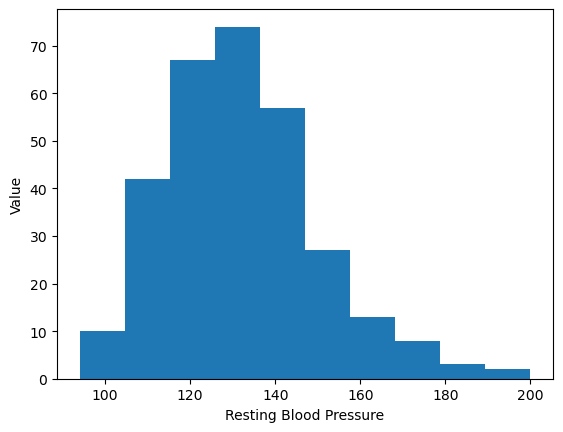

In [7]:
plt.hist(df['trestbps'])
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Value')
plt.show()

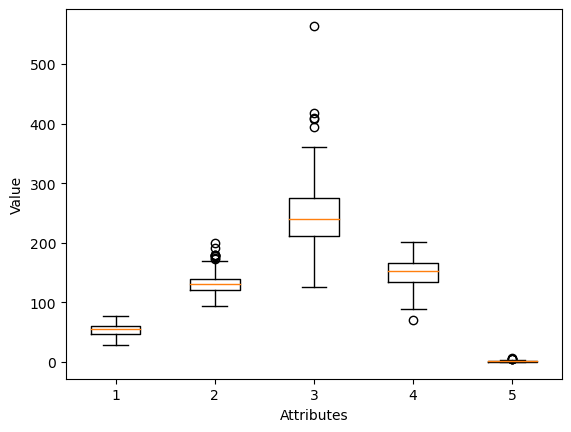

In [8]:
data_to_boxplot = [df['age'], df['trestbps'], df['chol'], 
df['thalach'], df['oldpeak']]
plt.boxplot(data_to_boxplot)
plt.xlabel('Attributes')
plt.ylabel('Value')
plt.show()

In [10]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [18]:
training_points= df.drop(columns=['target'])
training_labels= df['target']
X_train, X_test, y_train, y_test= train_test_split(
training_points, 
training_labels, 
test_size=0.2, 
random_state=4)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(242, 13)
(242,)
(61, 13)
(61,)


In [19]:
classifier = KNeighborsClassifier(n_neighbors = 5)
classifier.fit(X_train, y_train)
guesses = classifier.predict(X_test)
print(guesses)
print(confusion_matrix(y_test, guesses))
print(metrics.accuracy_score(y_test, guesses))

[1 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1
 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0]
[[13 12]
 [14 22]]
0.5737704918032787


[0.5409836065573771, 0.6229508196721312, 0.7049180327868853, 0.6885245901639344, 0.5737704918032787, 0.639344262295082, 0.639344262295082, 0.5901639344262295, 0.639344262295082, 0.6885245901639344, 0.6885245901639344, 0.6885245901639344, 0.6721311475409836, 0.6885245901639344, 0.7049180327868853, 0.7213114754098361, 0.7049180327868853, 0.7213114754098361, 0.7213114754098361, 0.7213114754098361, 0.7213114754098361, 0.7213114754098361, 0.7213114754098361, 0.7213114754098361, 0.7049180327868853, 0.7049180327868853, 0.7049180327868853, 0.6885245901639344, 0.7049180327868853, 0.7213114754098361, 0.7377049180327869, 0.7049180327868853, 0.6721311475409836, 0.6721311475409836, 0.6557377049180327, 0.6721311475409836, 0.6721311475409836, 0.6557377049180327, 0.7213114754098361, 0.7049180327868853, 0.6721311475409836, 0.6557377049180327, 0.639344262295082, 0.6557377049180327, 0.639344262295082, 0.6721311475409836, 0.6557377049180327, 0.7049180327868853, 0.6721311475409836]


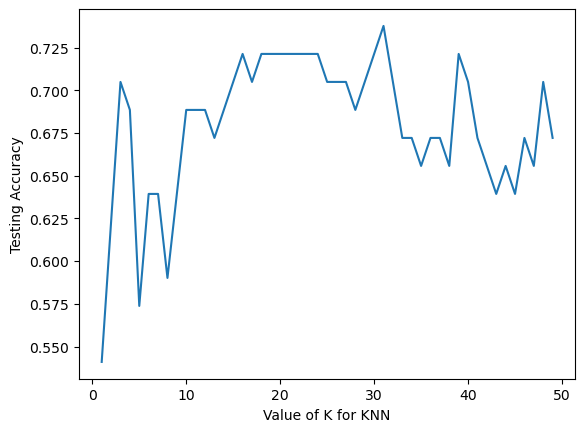

In [20]:
k_range= range(1, 50)
accuracy_scores= []

for k in k_range:
     classifier = KNeighborsClassifier(n_neighbors= k)
     classifier.fit(X_train, y_train)
     guesses = classifier.predict(X_test)
     accuracy_scores.append(metrics.accuracy_score(y_test, guesses))
print(accuracy_scores)

#Visualize the result of KNN accuracy with matplotlib
plt.plot(k_range, accuracy_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.show()

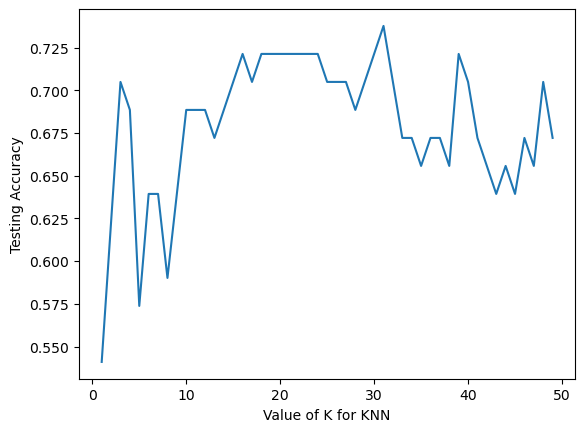

In [23]:
from sklearn.preprocessing import StandardScaler

#Create copy of dataset.
df_model= df.copy()
#Rescaling features age, trestbps, chol, thalach, oldpeak.
scaler = StandardScaler()
features = [['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]
for feature in features:
    df_model[feature] = scaler.fit_transform(df_model[feature])
training_points= df_model.drop(columns=['target'])
training_labels= df_model['target']

#Visualize the result of KNN accuracy with matplotlib
plt.plot(k_range, accuracy_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.show()